____
# Colocalization dataset
- put all variables for reconstruction in the same file


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from swot import browse_swot_250, add_mask_inside_swot, build_swath_polygon
from diagnosis import dataset_coloc_combs, DRIFTER, ALTI, WD, dataset_coloc_combs, DRIFTER, ALTI, WD, prepared_drifters, prepared_wd, prepared_alti, compute_mean_square, compute_mean_square_groupby

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

_______
# Data

In [2]:
DRIFTER.keys(), ALTI.keys(), WD.keys()
# wd_depth = '0' or '15'
# ggd_var = 'etaf', 'etac', 'adtf', 'adtc', 'fromduacsv'

(dict_keys(['nofilter']),
 dict_keys(['swot250naive', 'swot2kmnaive', 'L4noswotregional', 'L4noswotglobal', 'L4withswot']),
 dict_keys(['era5']))

_______
# Surface

In [19]:
comb_list = [dict(drifter_key='nofilter', alti_key = 'swot250naive', wd_key = 'era5',wd_model='rio', ggd_var='etaf', wd_depth='0'),
            dict(drifter_key='nofilter', alti_key = 'swot2kmnaive', wd_key = 'era5', wd_model='rio',ggd_var='etaf', wd_depth='0'),
             dict(drifter_key='nofilter', alti_key = 'L4noswotregional', wd_key = 'era5',wd_model='rio', ggd_var='adt', wd_depth='0'),
             dict(drifter_key='nofilter', alti_key = 'L4noswotglobal', wd_key = 'era5',wd_model='rio', ggd_var='adt', wd_depth='0'),
             dict(drifter_key='nofilter', alti_key = 'L4withswot', wd_key = 'era5',wd_model='rio', ggd_var='adt', wd_depth='0'),
]

#DS = dataset_coloc_combs(comb_list, nearest =False)
#DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')<12).dropna('row_number')
#DSS = DS.where(DS.depth==0, drop=True)

# Closure figs
ds = compute_mean_square(DSS)/U2
df = ds.to_dataframe()

df['Pressure gradient'] = ['L3-250m-SWOT', 'L3-2km-SWOT','L4-regional-noSWOT','L4-global-noSWOT', 'L4-SWOT',]
df = df.reset_index().set_index('Pressure gradient')






In [20]:
DSS

<xarray.Dataset> Size: 238MB
Dimensions:        (id_comb: 5, row_number: 147938)
Coordinates:
    datetime       (id_comb, row_number) datetime64[ns] 6MB 2023-04-01T11:50:...
    longitude      (id_comb, row_number) float64 6MB 5.538 5.539 ... 2.192 2.189
    latitude       (id_comb, row_number) float64 6MB 42.31 42.31 ... 41.09 41.09
    pass_number    (id_comb, row_number) float64 6MB 3.0 3.0 3.0 ... 16.0 16.0
    time_to_swot   (id_comb, row_number) timedelta64[ns] 6MB 11:52:32.696536 ...
    cycle_number   (id_comb, row_number) float64 6MB 478.0 478.0 ... 577.0 577.0
    drifter_id     (id_comb, row_number) object 6MB '0-4351296' ... '295'
    drifter_type   (id_comb, row_number) object 6MB 'CARTHE' ... 'HEREON'
    depth          (id_comb, row_number) float64 6MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    phi            (id_comb, row_number) float64 6MB 0.2456 0.2458 ... 0.0 0.0
  * row_number     (row_number) int64 1MB 144 145 146 ... 376322 376323 376324
  * id_comb        (id_comb) <U41 820B 'nofilter__swot250naive_etaf__rio_0era...
Data variables: (12/30)
    sume           (id_comb, row_number) float64 6MB -2.585e-05 ... -7.707e-06
    acce           (id_comb, row_number) float64 6MB -7.905e-06 ... -4.659e-06
    exce_acc       (id_comb, row_number) float64 6MB -1.794e-05 ... -3.048e-06
    core           (id_comb, row_number) float64 6MB 1.226e-05 ... 3.609e-06
    exce_cor       (id_comb, row_number) float64 6MB -3.811e-05 ... -1.132e-05
    ggde           (id_comb, row_number) float64 6MB -1.229e-06 ... -9.027e-06
    ...             ...
    prodn_acc_cor  (id_comb, row_number) float64 6MB 3.142e-11 ... -4.262e-10
    prodn_acc_ggd  (id_comb, row_number) float64 6MB -3.171e-11 ... 4.79e-11
    prodn_acc_wd   (id_comb, row_number) float64 6MB -2.746e-11 ... 5.181e-12
    prodn_cor_ggd  (id_comb, row_number) float64 6MB -2.167e-10 ... -1.062e-10
    prodn_cor_wd   (id_comb, row_number) float64 6MB -1.877e-10 ... -1.149e-11
    prodn_ggd_wd   (id_comb, row_number) float64 6MB 1.894e-10 ... 1.291e-12

147938
9.496911892467017
9.978624000650415
9.990449055942785
10.148461859017935
8.026736705503268
8.432217578033773
8.082899207951375
8.294687152944775
7.161963588249967
7.501791086817193
6.62125109502744
6.806796070772552
7.075146507248391
7.370507145939639
6.45717487279136
6.617709375393956
7.207044290649137
7.552508331336272
6.697670516497512
6.897360360150239


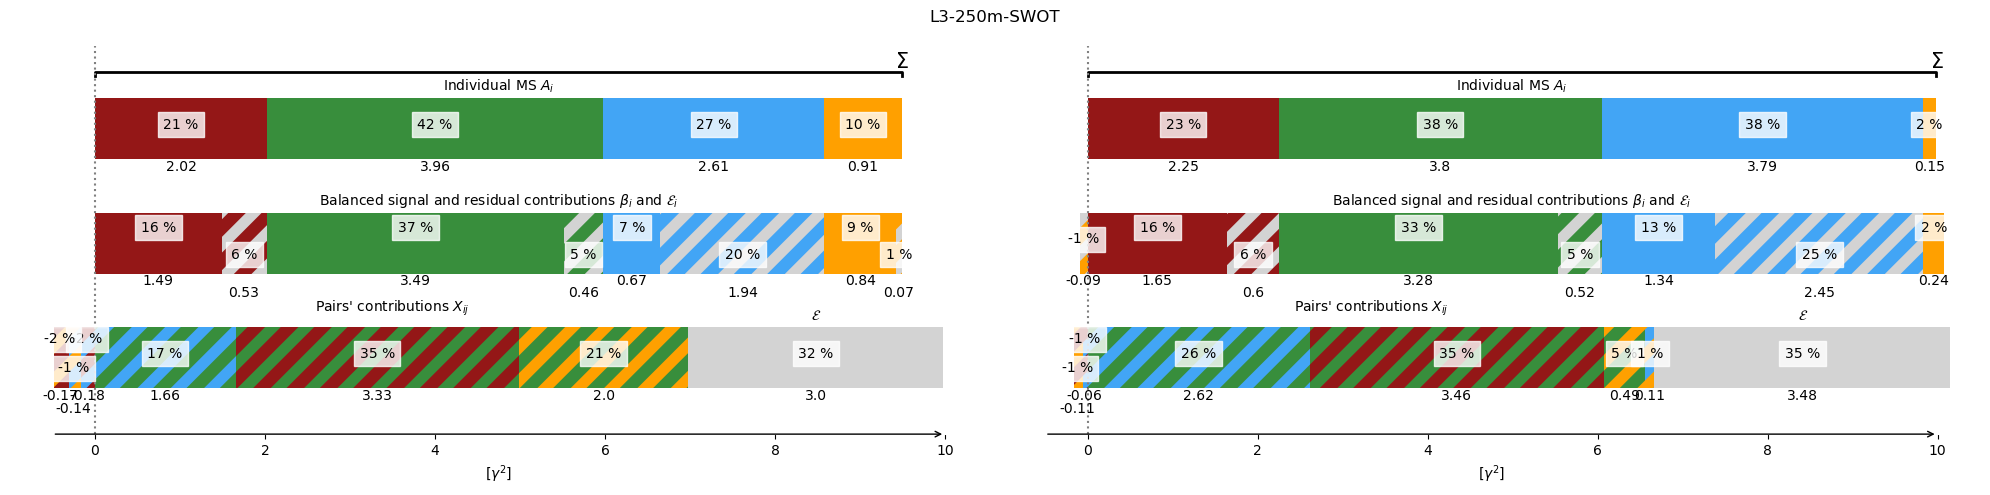

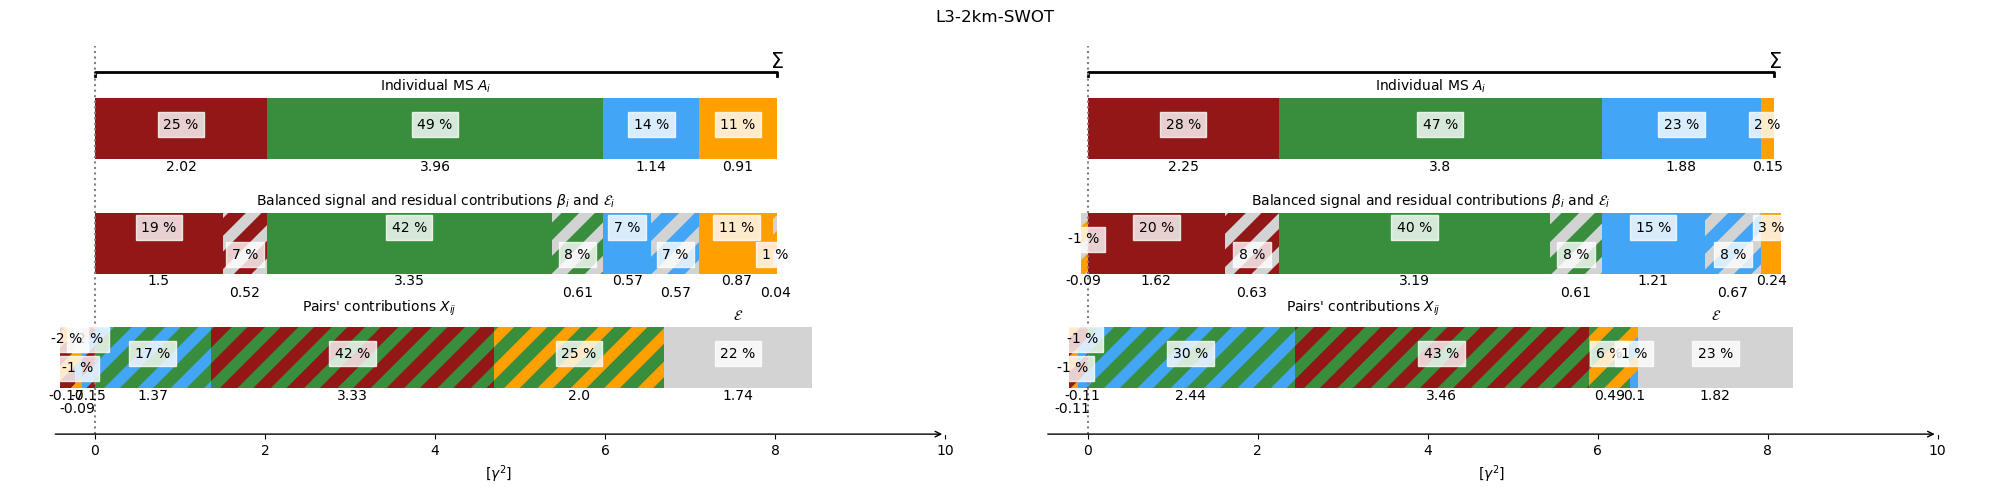

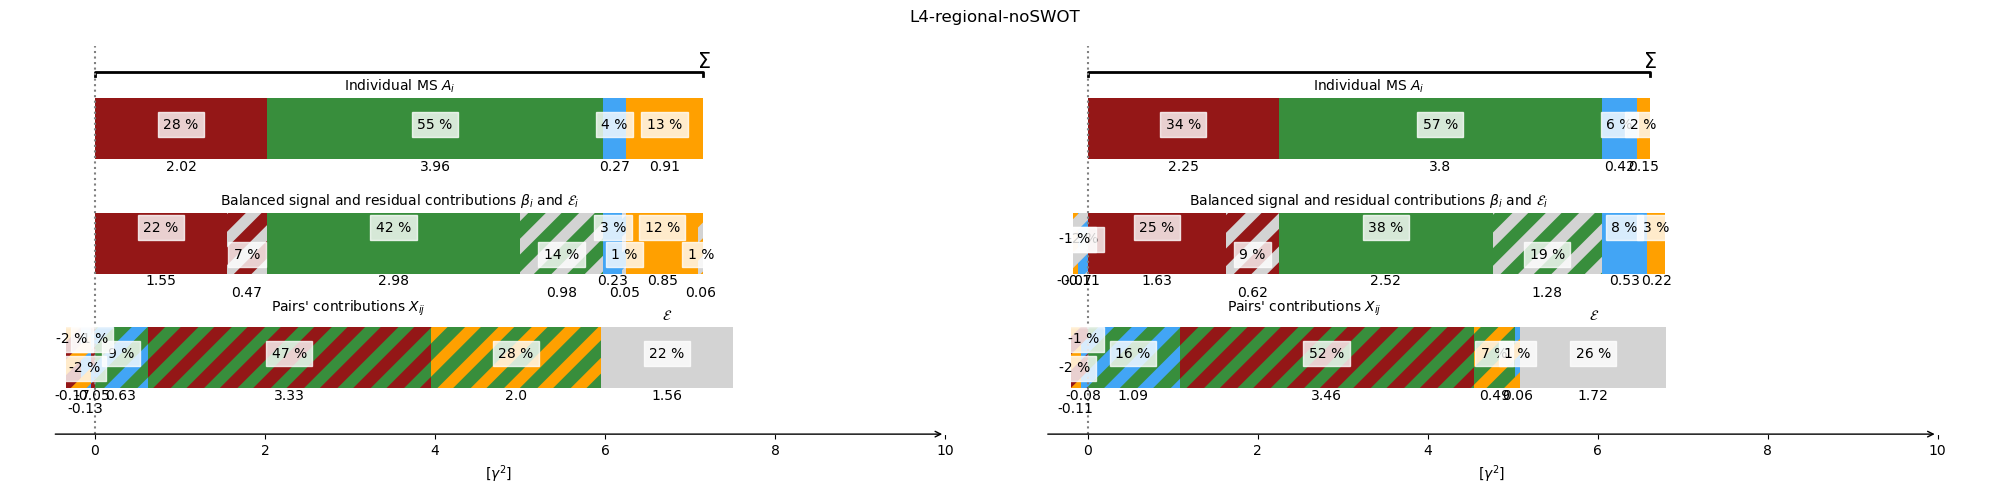

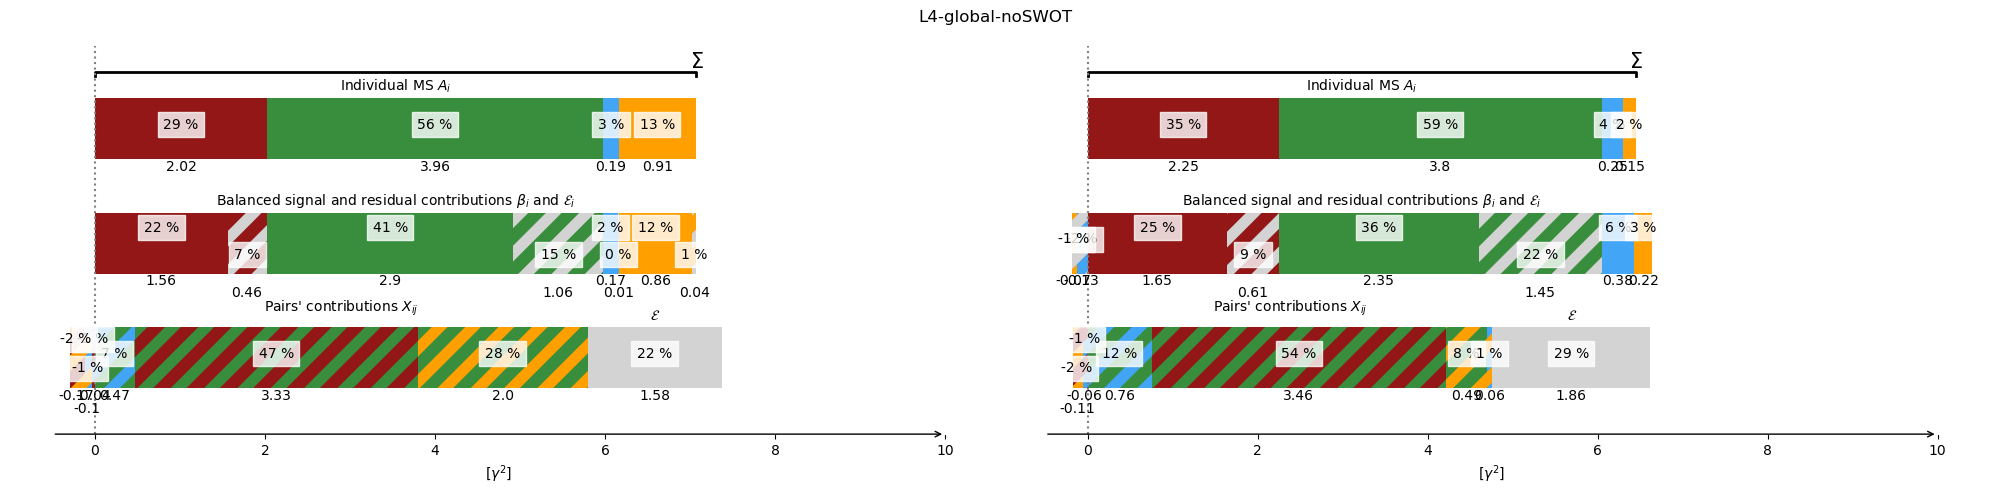

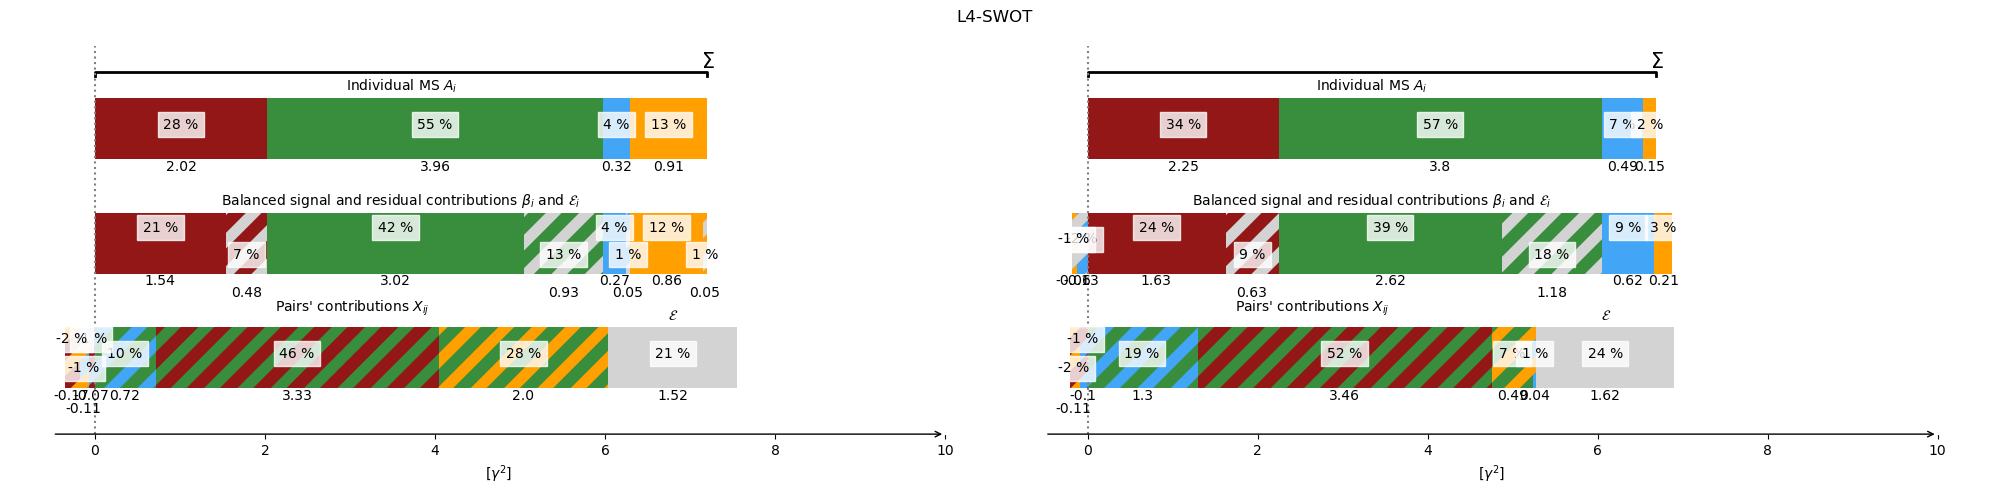

In [21]:
# Closure figs
print(DSS.sizes['row_number'])
for c in df.index :
    plt.rcParams["axes.edgecolor"] = "w"
    fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(20,5), frameon=False)
    synthetic_figure(df.loc[c], axs[0], dir='e', xlim=[-1, 10])
    synthetic_figure(df.loc[c], axs[1], dir='n', xlim=[-1, 10])
    fig.suptitle(c)
    fig.tight_layout()
    fig.savefig(os.path.join(images_dir, 'closure_figs', '15m_' + c + '.png'))


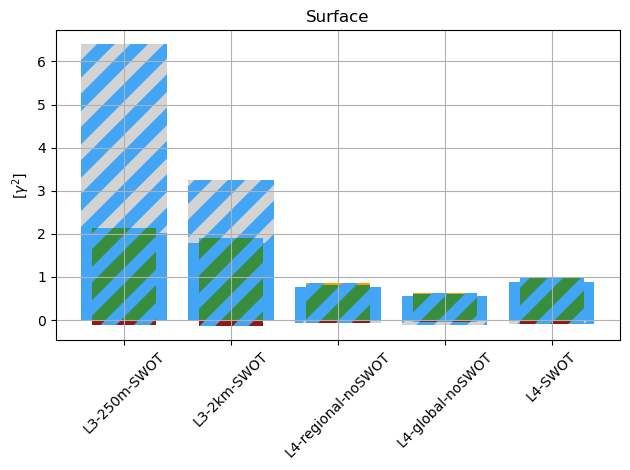

In [23]:
# Alti comparison
fig, ax = plt.subplots(frameon=False)
plt.rcParams["axes.edgecolor"] = "k"
for i in range(len(df)):
    df_ = df.iloc[i]
    # residual contribution
    plt.rcParams["hatch.linewidth"] = 8
    plt.rcParams["hatch.color"] = "lightgrey"
    if df_.E_ggd>0: ax.bar(i, df_.E_ggd, bottom = df.B_ggd,color = c0['ggd'], hatch="/")
    else: ax.bar(i, df_.E_ggd, color = c0['ggd'], hatch="/")
    ax.bar(i, df_.B_ggd,color = c0['ggd'])

    plt.rcParams["hatch.color"] = c0['ggd']
    ax.bar(i, df_.X_acc_ggd/2, color = c0['acc'], hatch="/", width=0.6)
    ax.bar(i, df_.X_cor_ggd/2, color = c0['cor'], hatch="/", width=0.6)
    ax.bar(i, df_.X_ggd_wd/2, color = c0['wd'], hatch="/", bottom = df_.X_cor_ggd/2, width=0.6)
    
ax.grid()
ax.set_ylabel(r'[$\gamma^2$]')
ax.set_xticks(ticks = np.arange(len(df)),labels = df.index, rotation = 45 )
ax.set_title('Surface')
fig.tight_layout()
fig.savefig(os.path.join(images_dir, 'alti_comparison', 'alti_comparison_surface_ggd_' + c + '.png'))


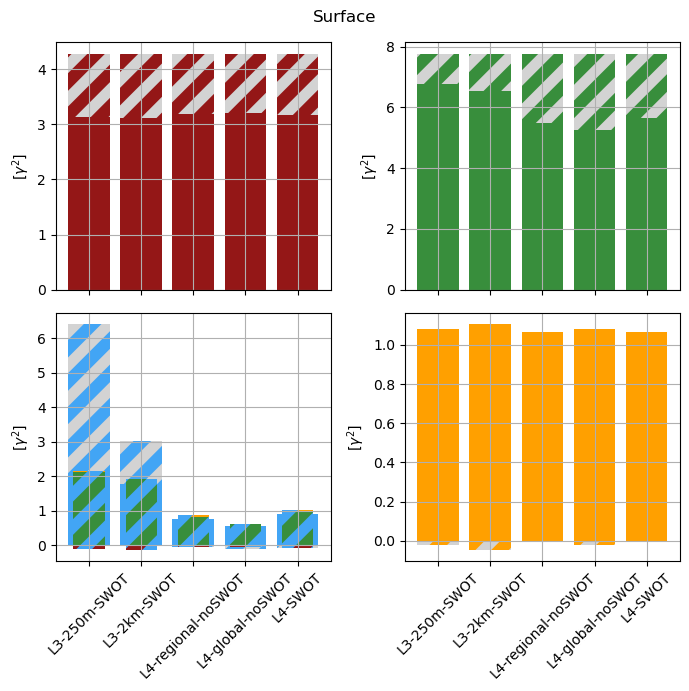

In [12]:
# Alti comparison
vars = ['acc', 'cor', 'ggd','wd']
plt.rcParams["axes.edgecolor"] = "k"
fig, axs = plt.subplots(2, 2, figsize = (7, 7), frameon=False, sharex=True)
axs = axs.flatten()
for i in range(len(df)):
    df_ = df.iloc[i]
    plt.rcParams["hatch.linewidth"] = 8
    for j in range(4):
        ax=axs[j]
        # residual contribution
        plt.rcParams["hatch.color"] = "lightgrey"
        if df_['E_'+vars[j]]>0: ax.bar(i, df_['E_'+vars[j]], bottom = df_['B_'+vars[j]],color = c0[vars[j]], hatch="/")
        else: ax.bar(i, df_['E_'+vars[j]], color = c0[vars[j]], hatch="/")
        ax.bar(i, df_['B_'+vars[j]],color = c0[vars[j]])


    ax = axs[2]
    plt.rcParams["hatch.color"] = c0['ggd']
    ax.bar(i, df_.X_acc_ggd/2, color = c0['acc'], hatch="/", width=0.6)
    ax.bar(i, df_.X_cor_ggd/2, color = c0['cor'], hatch="/", width=0.6)
    ax.bar(i, df_.X_ggd_wd/2, color = c0['wd'], hatch="/", bottom = df_.X_cor_ggd/2, width=0.6)

for ax in axs :    
    ax.grid()
    ax.set_ylabel(r'[$\gamma^2$]')
    ax.set_xticks(ticks = np.arange(len(df)),labels = df.index, rotation = 45 )
fig.suptitle('Surface')
fig.tight_layout()
fig.savefig(os.path.join(images_dir, 'alti_comparison', 'alti_comparison_surface_all_' + c + '.png'))


# Depth =15m

In [13]:
comb_list = [dict(drifter_key='nofilter', alti_key = 'swot250naive', wd_key = 'era5', ggd_var='etaf', wd_depth='15'),
            dict(drifter_key='nofilter', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='15'),
             dict(drifter_key='nofilter', alti_key = 'L4noswotregional', wd_key = 'era5', ggd_var='adt', wd_depth='15'),
             dict(drifter_key='nofilter', alti_key = 'L4noswotglobal', wd_key = 'era5', ggd_var='adt', wd_depth='15'),
             dict(drifter_key='nofilter', alti_key = 'L4withswot', wd_key = 'era5', ggd_var='adt', wd_depth='15'),
]

DS = dataset_coloc_combs(comb_list, nearest =False)
DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')<12).dropna('row_number')
DSD = DS.where(DS.depth==15, drop=True)


ds = compute_mean_square(DSD)/U2
df = ds.to_dataframe()

df['Pressure gradient'] = ['L3-250m-SWOT', 'L3-2km-SWOT','L4-regional-noSWOT','L4-global-noSWOT', 'L4-SWOT',]
df = df.reset_index().set_index('Pressure gradient')

nofilter__swot250naive_etaf__rio_15era5
nofilter__swot2kmnaive_etaf__rio_15era5
nofilter__L4noswotregional_adt__rio_15era5
nofilter__L4noswotglobal_adt__rio_15era5
nofilter__L4withswot_adt__rio_15era5
Identified SWOT and drifter outliers have been removed


5.853613642158059
5.989655275392735
7.106325885679414
7.324545165399574
4.820544871921339
4.978065903550418
5.885165190622785
6.091280991347079
4.0624746436547134
4.296435765472843
4.6595922159430385
4.7295215624503895
3.95764365224236
4.1788064502236795
4.444166981214774
4.494597347627956
4.151017721177442
4.382141328846164
4.759096474906246
4.863398630142633


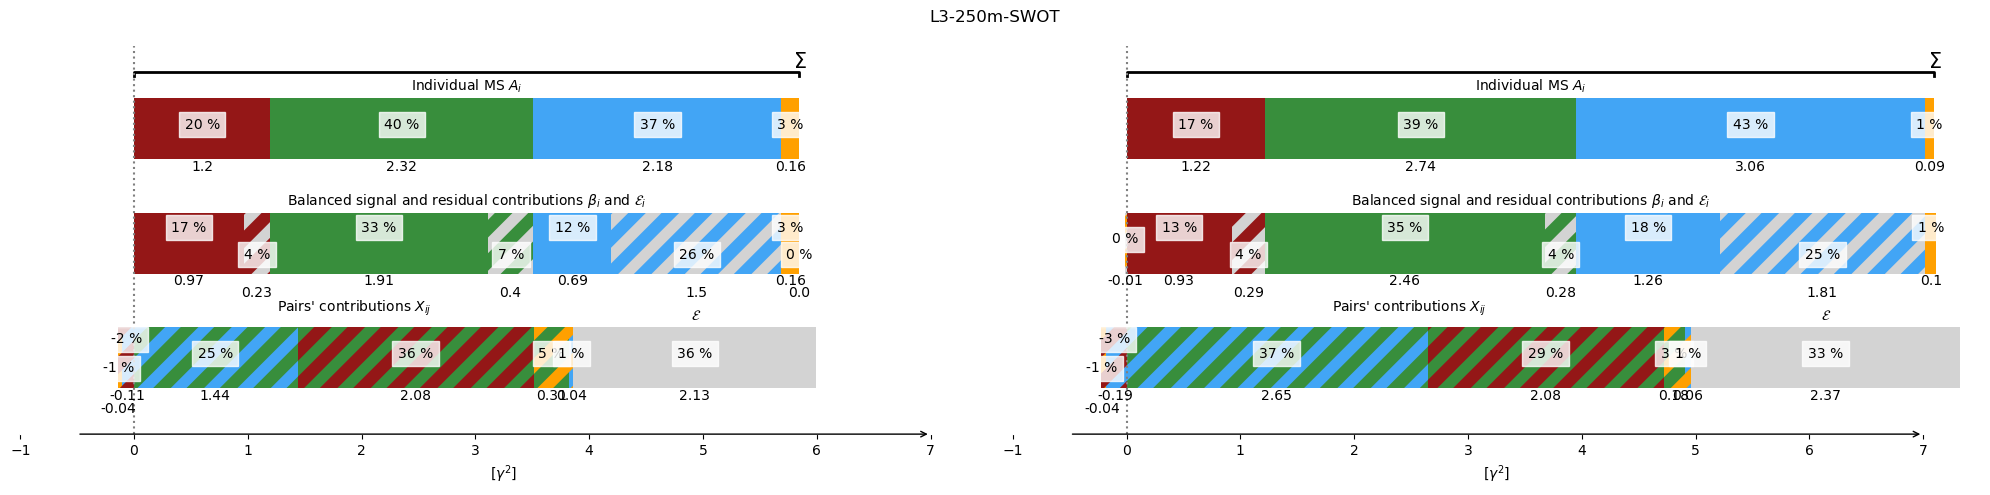

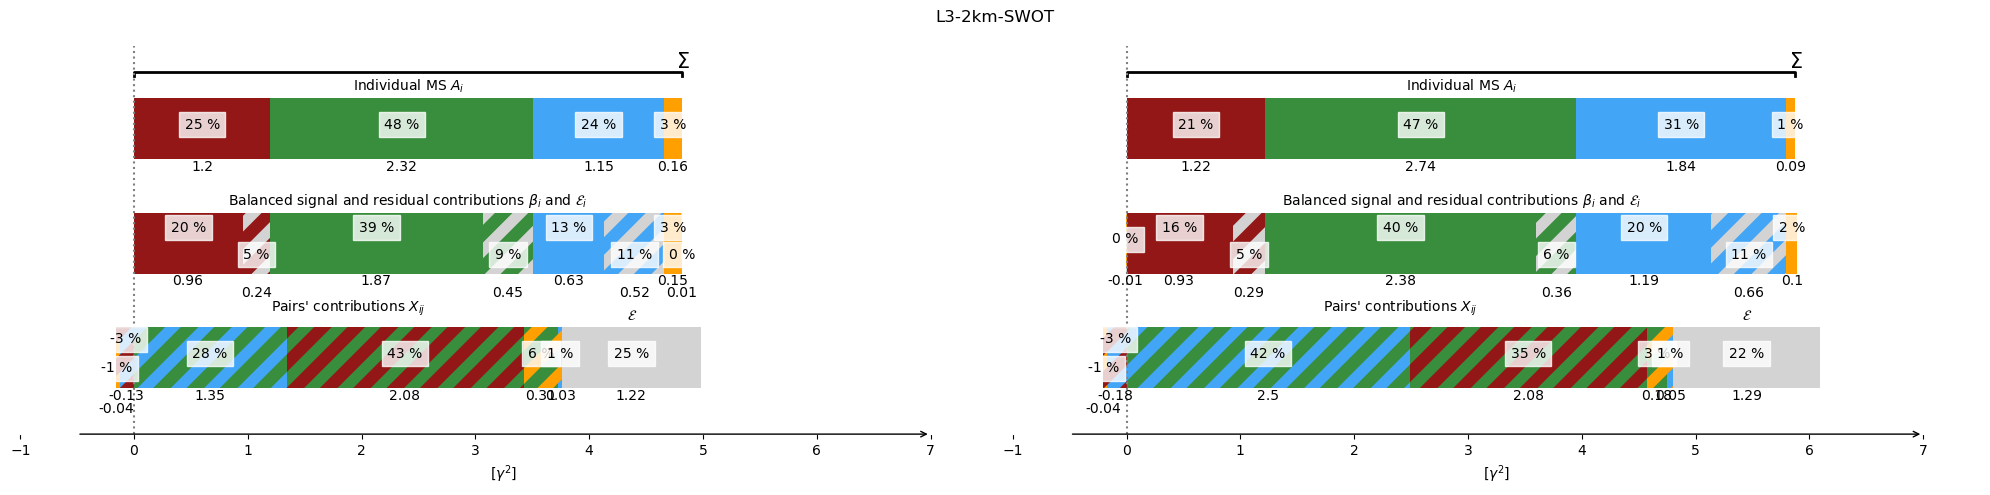

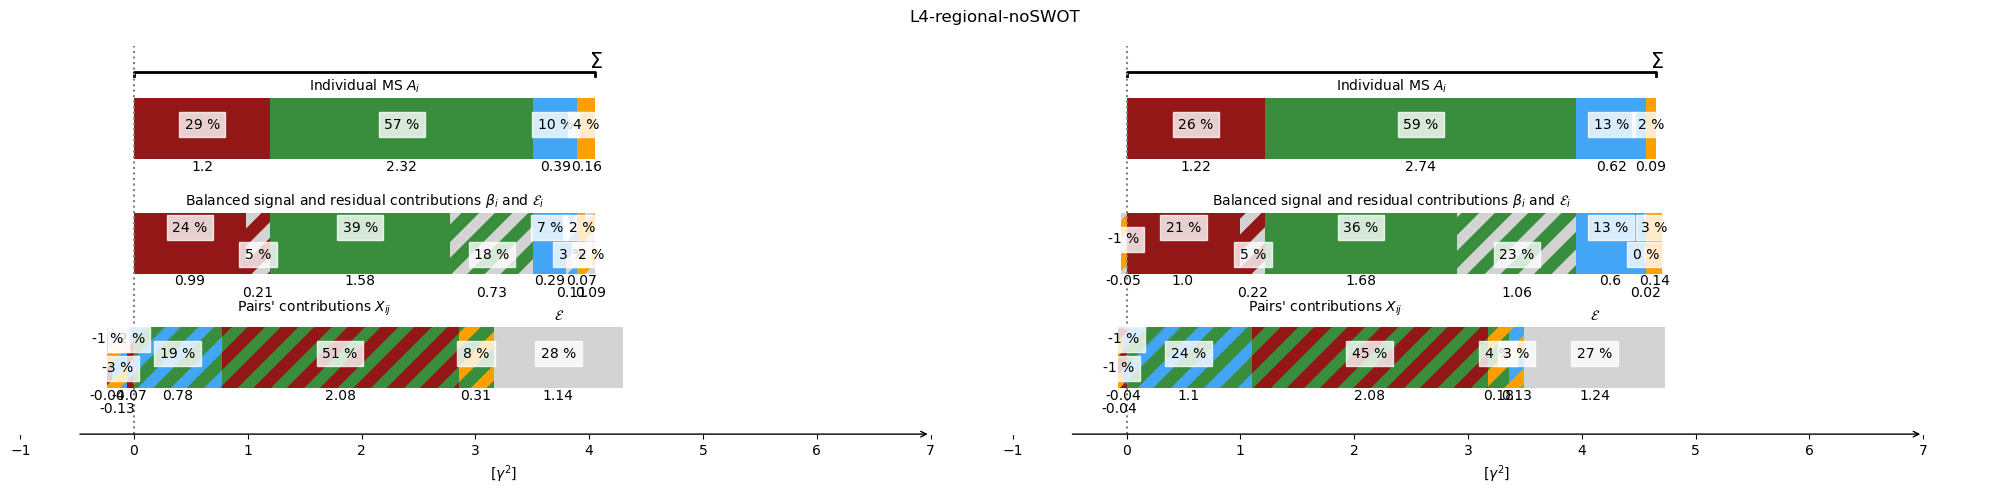

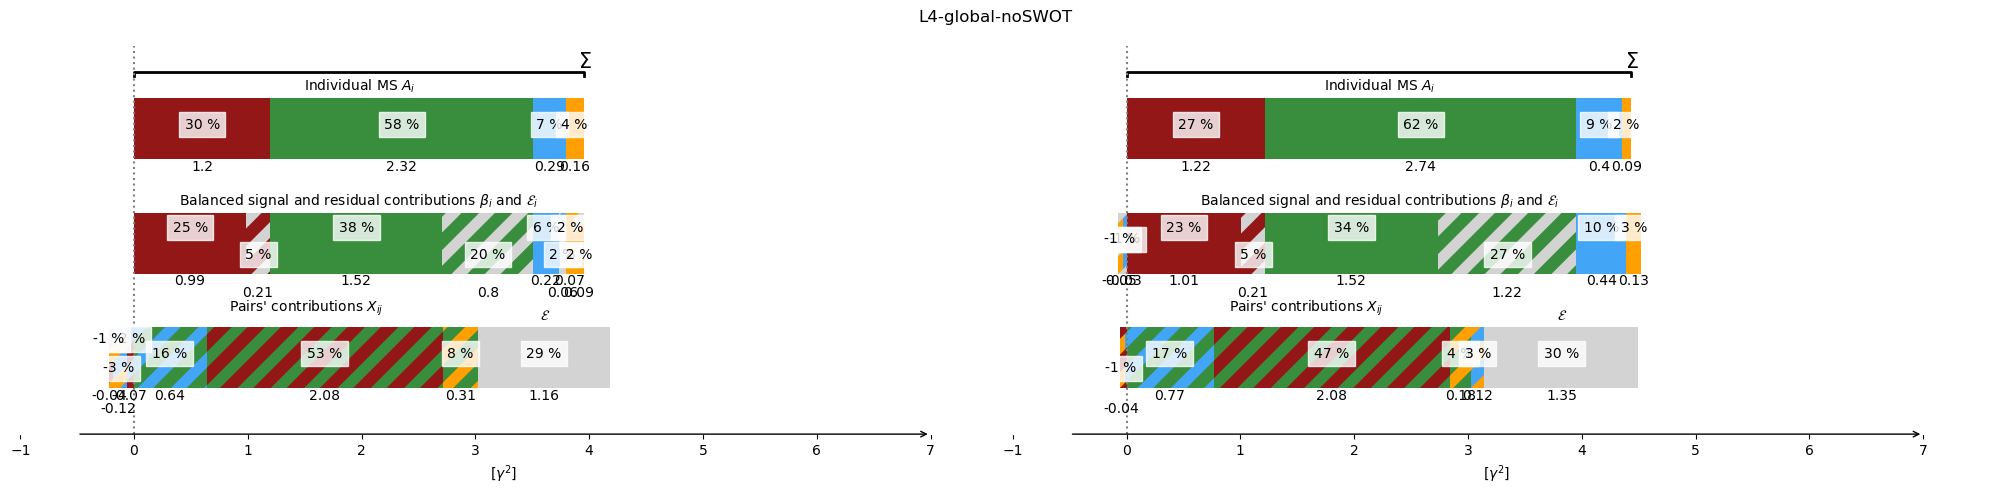

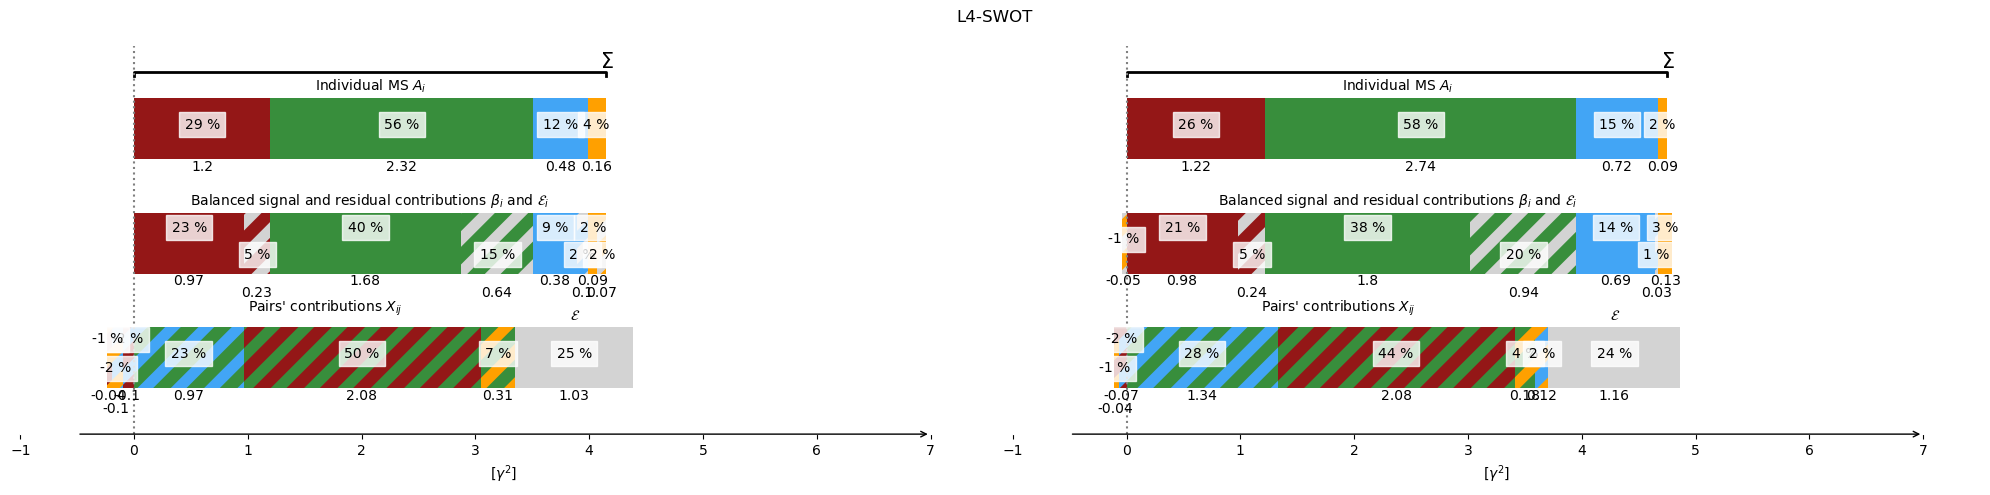

In [14]:
# Closure figs
for c in df.index :
    plt.rcParams["axes.edgecolor"] = "w"
    fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(20,5), frameon=False)
    synthetic_figure(df.loc[c], axs[0], dir='e', xlim=[-1, 7])
    synthetic_figure(df.loc[c], axs[1], dir='n', xlim=[-1, 7])
    fig.suptitle(c)
    fig.tight_layout()
    fig.savefig(os.path.join(images_dir, 'closure_figs', '15m_' + c + '.png'))


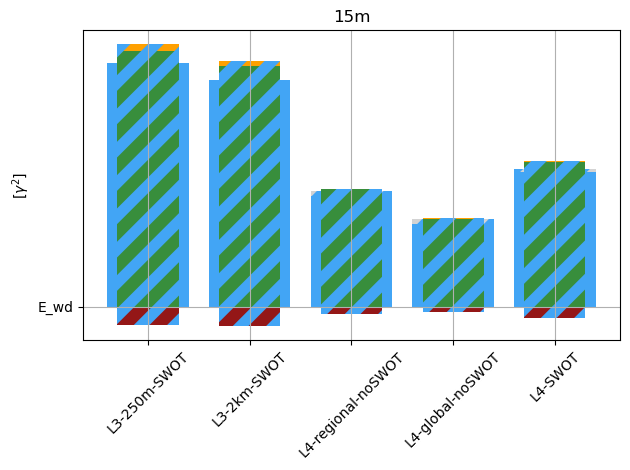

In [18]:
# Alti comparison
plt.rcParams["axes.edgecolor"] = "k"
fig, ax = plt.subplots(frameon=False)
for i in range(len(df)):
    df_ = df.iloc[i]
    # residual contribution
    plt.rcParams["hatch.linewidth"] = 8
    plt.rcParams["hatch.color"] = "lightgrey"
    if df_['E_'+vars[j]]>0: ax.bar(i, df_['E_'+vars[j]], bottom = df_.B_ggd,color = c0['ggd'], hatch="/")
    else: ax.bar(i, ['E_'+vars[j]], color = c0['ggd'], hatch="/")
    ax.bar(i, df_.B_ggd,color = c0['ggd'])

    plt.rcParams["hatch.color"] = c0['ggd']
    ax.bar(i, df_.X_acc_ggd/2, color = c0['acc'], hatch="/", width=0.6)
    ax.bar(i, df_.X_cor_ggd/2, color = c0['cor'], hatch="/", width=0.6)
    ax.bar(i, df_.X_ggd_wd/2, color = c0['wd'], hatch="/", bottom = df_.X_cor_ggd/2, width=0.6)
    
ax.grid()
ax.set_ylabel(r'[$\gamma^2$]')
ax.set_xticks(ticks = np.arange(len(df)),labels = df.index, rotation = 45 )
ax.set_title('15m')
fig.tight_layout()
fig.savefig(os.path.join(images_dir, 'alti_comparison', 'alti_comparison_15m_' + c + '.png'))
